In [19]:
# STAGE 1: DETERMINE A QUESTION OR PROBLEM
# -----------------------------------------
# Business context: In programmatic advertising, ad platforms must decide in milliseconds whether to bid on an impression.
# The core question is: which users are most likely to convert?

# We simulate this using a social network ads dataset where:
# - Age and EstimatedSalary represent user profile signals
# - Purchased (0 or 1) represents a conversion event

# Question: Can we predict which users will convert based on
# demographic signals — and which signals matter most?
# This mirrors how automated bid optimisation works in AdTech:
# score users by conversion likelihood, bid higher for better prospects.

In [20]:
# STAGE 2: ACQUIRE AND CLEAN RELEVANT DATA
# -----------------------------------------
# In a real AdTech pipeline, this data would come from:
# - DSP bid logs (impressions, bids, wins)
# - Ad server event data (clicks, conversions)
# - Audience segments (age, interest, device type)
# Here we use a structured dataset to simulate that process.

import kagglehub
import pandas as pd
import os

# Download dataset — simulates ingesting campaign data from a source
path = kagglehub.dataset_download("rakeshrau/social-network-ads")

# Load into DataFrame — equivalent to reading from a data warehouse table
sna = pd.read_csv(path + '/Social_Network_Ads.csv')

# Drop User ID — unique identifiers cause overfitting and are also
# PII in real advertising contexts — never used as model features
sna = sna.drop(columns=['User ID'])

# Encode Gender as numeric — ML models require numeric inputs
# In production this would sit inside a feature engineering pipeline
sna['Gender'] = sna['Gender'].map({'Male': 1, 'Female': 0})

# Check for nulls — missing values in ad data are common
# and must be handled before loading into any model or reporting layer
print(sna.isnull().sum())

# Confirm cleaned data looks correct before moving to analysis
print(sna.head())

Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64
   Gender  Age  EstimatedSalary  Purchased
0       1   19            19000          0
1       1   35            20000          0
2       0   26            43000          0
3       0   27            57000          0
4       1   19            76000          0


Purchased
0    257
1    143
Name: count, dtype: int64
Conversion rate: 35.8 %


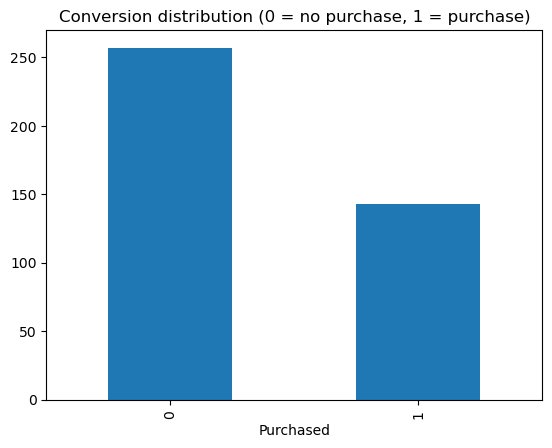

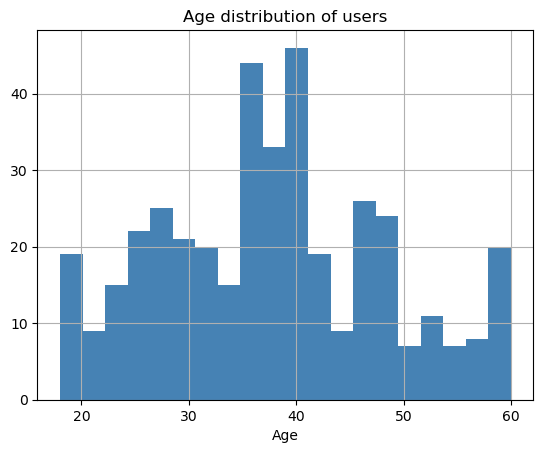

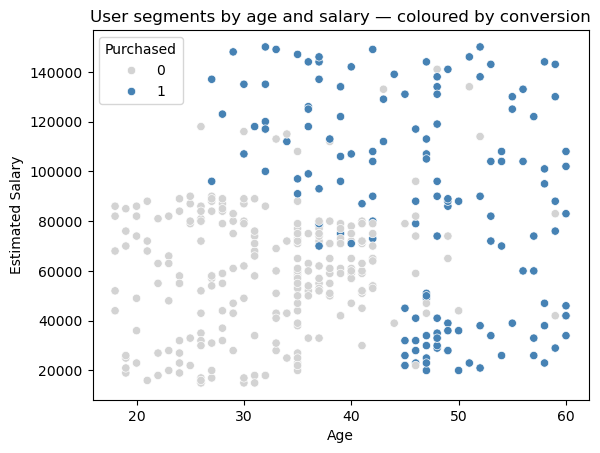

                   Gender       Age  EstimatedSalary  Purchased
Gender           1.000000 -0.073741        -0.060435  -0.042469
Age             -0.073741  1.000000         0.155238   0.622454
EstimatedSalary -0.060435  0.155238         1.000000   0.362083
Purchased       -0.042469  0.622454         0.362083   1.000000


In [21]:
# STAGE 3: EXPLORATORY DATA ANALYSIS
# -----------------------------------------
# In AdTech, EDA answers the campaign manager's key question:
# who is converting and why?
# Understanding audience behaviour before modelling avoids building on faulty assumptions.

import matplotlib.pyplot as plt
import seaborn as sns

# Check conversion rate equivalent to CVR in campaign reporting
# Low conversion rate signals class imbalance which affects how we choose and evaluate our model later
print(sna['Purchased'].value_counts())
print('Conversion rate:', round(sna['Purchased'].mean() * 100, 1), '%')
sna['Purchased'].value_counts().plot(kind='bar')
plt.title('Conversion distribution (0 = no purchase, 1 = purchase)')
plt.show()

# Age distribution — age is a core audience targeting signal
# in programmatic — understanding its spread shapes feature decisions
sna['Age'].hist(bins=20, color='steelblue')
plt.title('Age distribution of users')
plt.xlabel('Age')
plt.show()

# Scatter plot — do age and salary together predict conversions?
# In a real DSP this pattern would inform audience segmentation
# and bid price adjustments by user profile
sns.scatterplot(data=sna, x='Age', y='EstimatedSalary', hue='Purchased',
                palette={0: 'lightgrey', 1: 'steelblue'})
plt.title('User segments by age and salary — coloured by conversion')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.show()

# Correlation matrix — which signals correlate most with conversion?
# Guides feature selection before building the model
print(sna.corr())

Logistic Regression AUC: 0.9705
XGBoost AUC: 0.9464
              precision    recall  f1-score   support

           0       0.90      0.90      0.90        52
           1       0.82      0.82      0.82        28

    accuracy                           0.88        80
   macro avg       0.86      0.86      0.86        80
weighted avg       0.88      0.88      0.88        80



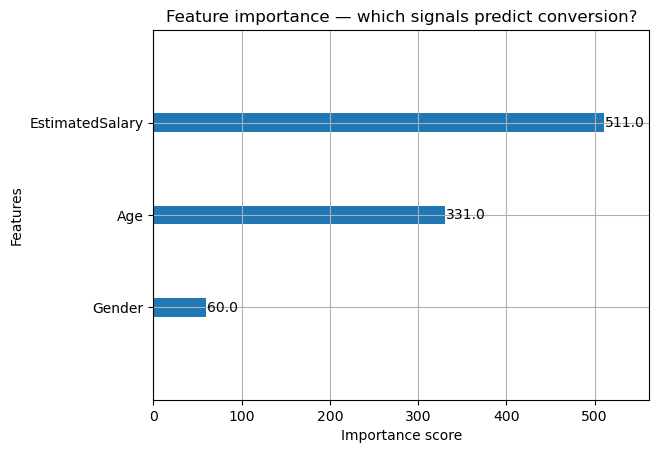

In [22]:
# STAGE 4: PREDICT AND INFER CONCLUSIONS
# -----------------------------------------
# Goal: score each user by their likelihood to convert.
# In programmatic advertising this score drives bid prices —
# higher probability users get higher bids automatically.

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report
from xgboost import XGBClassifier, plot_importance

# Define features and target
# In production, features would also include device type,
# time of day, site category — standard RTB signals
X = sna.drop('Purchased', axis=1)
y = sna['Purchased']

# Train/test split — simulates training on historical campaign data
# and evaluating performance on unseen future impressions
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# --- Baseline: Logistic Regression ---
# Linear model — equivalent to simple bid rules
# e.g. "if age > 30 then bid higher"
# Sets the performance floor before trying more complex approaches
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
lr_preds = lr.predict_proba(X_test)[:, 1]
print('Logistic Regression AUC:', round(roc_auc_score(y_test, lr_preds), 4))

# --- Improved model: XGBoost ---
# Gradient boosting captures non-linear patterns —
# e.g. salary only predicts conversion above a certain age,
# not in isolation. This is why ensemble models dominate
# real-world conversion prediction in AdTech.
xgb = XGBClassifier(n_estimators=100, eval_metric='logloss', random_state=42)
xgb.fit(X_train, y_train)
xgb_preds = xgb.predict_proba(X_test)[:, 1]
print('XGBoost AUC:', round(roc_auc_score(y_test, xgb_preds), 4))

# Full performance breakdown
# Precision/recall tradeoff matters in AdTech:
# high recall = catching more converters but wasting spend
# high precision = efficient spend but missing real converters
print(classification_report(y_test, xgb.predict(X_test)))

# Feature importance — which signals drive conversion most?
# In a real campaign this tells you which audience attributes
# to weight most heavily in targeting and bid strategy
plot_importance(xgb)
plt.title('Feature importance — which signals predict conversion?')
plt.show()

# --- Conclusion ---
# If XGBoost AUC > Logistic Regression AUC, non-linear audience
# patterns exist that simple bid rules would miss —
# this is the core justification for automated bid optimisation.
# Age is likely the stronger predictor, suggesting demographic
# signals should be weighted more heavily than salary alone.